In [22]:
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
import seaborn as sns
import tqdm

from networks import InvariantValueNet, ValueNet
from utils import get_batches


In [23]:
random_key = jax.random.PRNGKey(42)

batch_size = 32
width = 32

value_net_equiv = InvariantValueNet(
    key=random_key,
    in_size=6 * 7 * 2,
    head_depth=2,
    head_width=width,
    body_depth=2,
    body_width=width,
    body_n_blocks=2,
    embed_dim=width,
    activation=jax.nn.gelu,
    n_actions=7,
    avg_symmetries=False,
    simple=False,
    name="equiv",
)


value_net_nosym = ValueNet(
    key=random_key,
    in_size=6 * 7 * 2,
    head_depth=2,
    head_width=width,
    body_depth=2,
    body_width=width,
    body_n_blocks=2,
    embed_dim=width,
    activation=jax.nn.gelu,
    n_actions=7,
    avg_symmetries=False,
    simple=False,
    name="nosym",
)

value_net_sym = ValueNet(
    key=random_key,
    in_size=6 * 7 * 2,
    head_depth=2,
    head_width=width,
    body_depth=2,
    body_width=width,
    body_n_blocks=2,
    embed_dim=width,
    activation=jax.nn.gelu,
    n_actions=7,
    avg_symmetries=True,
    simple=False,
    name="sym",
)


In [24]:
opt = optax.adam(1e-3)

value_nets = [value_net_equiv, value_net_sym, value_net_nosym]
opts = []
for value_net in value_nets:
    params = eqx.filter(value_net, eqx.is_inexact_array)
    opts.append(opt.init(params))

_train_boards = np.load("data/train_boards.npy")
_train_values = np.load("data/train_values.npy")
_test_boards = np.load("data/test_boards.npy")
_test_values = np.load("data/test_values.npy")


n_train = _train_boards.shape[0]
n_sample = int(n_train * 0.1)
random_key, subkey = jax.random.split(random_key)
indices = jax.random.choice(subkey, n_train, shape=(n_sample,), replace=False)
train_boards = jnp.stack(
    [_train_boards[indices] == 1, _train_boards[indices] == 2], axis=-1
).astype(jnp.float32)
train_values = jnp.asarray(_train_values[indices], dtype=jnp.float32)
test_boards = jnp.stack([_test_boards == 1, _test_boards == 2], axis=-1).astype(
    jnp.float32
)
test_values = jnp.asarray(_test_values, dtype=jnp.float32)


@eqx.filter_jit
def do_epoch(
    random_key,
    value_net,
    opt_state,
    obs,
    values,
    opt,
    batch_size,
    alpha=0.0,
    interm_alpha=0.0,
):
    params, static = eqx.partition(value_net, eqx.is_inexact_array)

    data = get_batches((obs, values), random_key, batch_size, drop_last=True)

    def body_fn(carry, x):
        params, opt_state = carry
        obs, values = x
        value_net = eqx.combine(params, static)

        (_, metrics), grads = eqx.filter_value_and_grad(loss_fn, has_aux=True)(
            value_net, obs, values, alpha, interm_alpha
        )
        updates, opt_state = opt.update(grads, opt_state)
        value_net = eqx.apply_updates(value_net, updates)
        params = eqx.filter(value_net, eqx.is_inexact_array)
        return (params, opt_state), (metrics)

    (params, opt_state), metrics = jax.lax.scan(body_fn, (params, opt_state), data)
    value_net = eqx.combine(params, static)
    return value_net, opt_state, metrics


@eqx.filter_jit
def loss_fn(value_net, obs, values, alpha=0.0, interm_alpha=0.0):
    preds, interms, blocks_interms, first, last = jax.vmap(value_net.forward)(obs)

    loss_main = jnp.mean((preds - values) ** 2)

    sym_obs = jnp.flip(obs, axis=2)  # obs shape is [N, 6, 7, 2]

    sym_preds, sym_interms, sym_blocks_interms, sym_first, sym_last = jax.vmap(
        value_net.forward
    )(sym_obs)
    inv_loss_final = jnp.mean((preds - sym_preds) ** 2)

    # interms loss components store
    interms_loss_components = {}
    # sum all interms components
    inv_loss_interms = 0.0
    for i in range(len(interms)):
        interms_loss_components[f"DenseResNetBlock{i}"] = jnp.mean(
            (interms[i] - sym_interms[i]) ** 2
        )
        inv_loss_interms += jnp.mean((interms[i] - sym_interms[i]) ** 2)
    for i in range(len(blocks_interms)):
        for j in range(len(blocks_interms[i])):
            interms_loss_components[f"linear_module{i}_{j}"] = jnp.mean(
                (blocks_interms[i][j] - sym_blocks_interms[i][j]) ** 2
            )
            inv_loss_interms += jnp.mean(
                (blocks_interms[i][j] - sym_blocks_interms[i][j]) ** 2
            )
    interms_loss_components["first"] = jnp.mean((first - sym_first) ** 2)
    inv_loss_interms += jnp.mean((first - sym_first) ** 2)
    interms_loss_components["last"] = jnp.mean((last - sym_last) ** 2)
    inv_loss_interms += jnp.mean((last - sym_last) ** 2)

    # TODO weight equivariance loss,
    # enforce Wx = Q W Px with P the symmetry and Q
    # the permutation, here Q permutation like arange(dim)[::-1]

    loss = loss_main + alpha * inv_loss_final + interm_alpha * inv_loss_interms

    return loss, {
        "value_loss": loss,
        "main_loss": loss_main,
        "inv_loss_final": inv_loss_final,
        "inv_loss_interms": inv_loss_interms,
        **interms_loss_components,
    }


In [25]:
rows = []
n_epochs = 10
k = 0


def append_metrics_to_rows(rows, eval_lossdict, k, model_name="noname"):
    for key, value in eval_lossdict.items():
        row = {"value": float(value), "step": k, "metric": f"{model_name}_{key}"}
        rows.append(row)
    return rows


for value_net in value_nets:
    eval_loss_sym, eval_dict = loss_fn(value_net_sym, test_boards, test_values)
    rows = append_metrics_to_rows(rows, eval_dict, k, value_net.name)

    if value_net.name == "nosym":
        value_net = eqx.combine(
            eqx.filter(value_net, eqx.is_inexact_array),
            eqx.filter(value_net_sym, lambda x: not eqx.is_inexact_array(x)),
        )
        rows = append_metrics_to_rows(rows, eval_dict, k, "nosym_evalsym")

In [26]:
for epoch in tqdm.trange(n_epochs):
    random_key, subkey = jax.random.split(random_key)

    new_value_nets, new_opts = [], []
    for value_net, opt_state in zip(value_nets, opts):
        value_net, opt_state, metrics = do_epoch(
            subkey,
            value_net,
            opt_state,
            train_boards,
            train_values,
            opt,
            batch_size,
        )
        new_value_nets.append(value_net)
        new_opts.append(opt_state)

    value_nets = new_value_nets
    opts = new_opts

    n_updates = len(metrics["value_loss"])
    k += n_updates

    for value_net in value_nets:
        eval_loss_sym, eval_dict = loss_fn(value_net_sym, test_boards, test_values)
        rows = append_metrics_to_rows(rows, eval_dict, k, value_net.name)

        if value_net.name == "nosym":
            value_net = eqx.combine(
                eqx.filter(value_net, eqx.is_inexact_array),
                eqx.filter(value_net_sym, lambda x: not eqx.is_inexact_array(x)),
            )
            rows = append_metrics_to_rows(rows, eval_dict, k, "nosym_evalsym")


  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:26<00:00,  2.67s/it]


In [42]:
df

,value,step,metric
0,0.187886,0,equiv_DenseResNetBlock0
1,0.282549,0,equiv_DenseResNetBlock1
2,0.011821,0,equiv_first
3,0.000000,0,equiv_inv_loss_final
4,1.092062,0,equiv_inv_loss_interms
...,...,...,...
523,0.175897,23320,nosym_evalsym_linear_module0_1
524,0.122250,23320,nosym_evalsym_linear_module1_0
525,0.073225,23320,nosym_evalsym_linear_module1_1
526,0.958028,23320,nosym_evalsym_main_loss


In [43]:
metric_keys

['DenseResNetBlock0',
 'DenseResNetBlock1',
 'first',
 'inv_loss_final',
 'inv_loss_interms',
 'last',
 'linear_module0_0',
 'linear_module0_1',
 'linear_module1_0',
 'linear_module1_1',
 'main_loss',
 'value_loss']

44
44
44
44
44
44
44
44
44
44
44
44


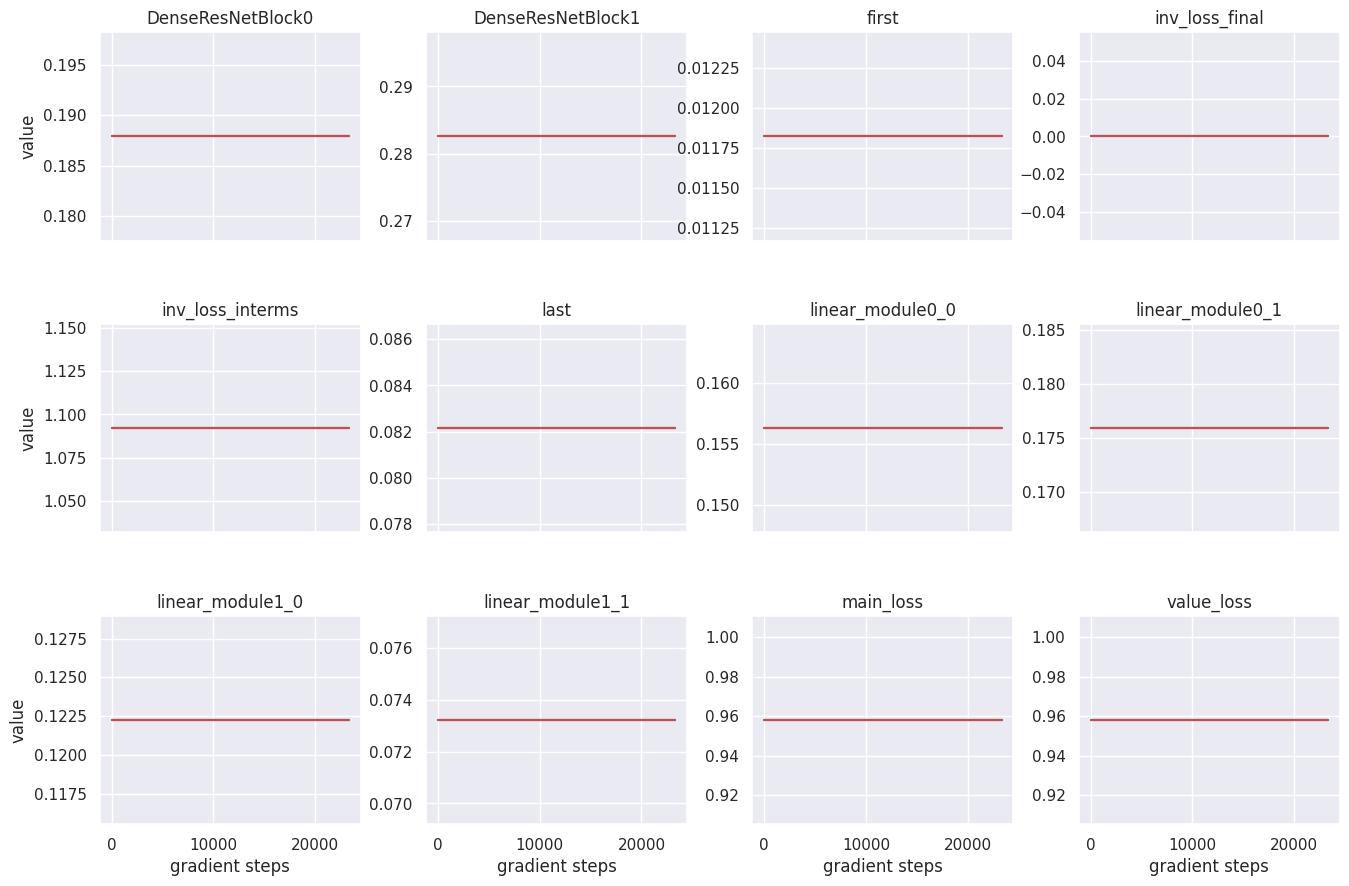

In [50]:
df = pd.DataFrame(rows)
metric_keys = eval_dict.keys()
sns.set_theme()
plot_df_all = df
# plot_df_all = df[df.metric.str.contains("eval")].copy()
# plot_df_all.loc[:, "metric"] = plot_df_all["metric"].str.replace(r"^eval_", "", regex=True)

nrows, ncols = 3, 4
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, 12),
    sharex=True,
    sharey=False,
)
axes = axes.ravel()

max_plots = nrows * ncols
metric_keys = list(metric_keys)
n_plots = min(len(metric_keys), max_plots)


for i in range(n_plots):
    metricname = metric_keys[i]
    ax = axes[i]

    plot_df = plot_df_all[plot_df_all.metric.str.endswith(metricname)]
    print(len(plot_df))
    sns.lineplot(
        data=plot_df,
        x="step",
        y="value",
        hue="metric",
        ax=ax,
        legend=(i == 0),
    )

    ax.set_title(metricname)

    if i >= (nrows - 1) * ncols:
        ax.set_xlabel("gradient steps")
    else:
        ax.set_xlabel("")

    if i % ncols != 0:
        ax.set_ylabel("")

    if i == 0:
        legend_handles, legend_labels = ax.get_legend_handles_labels()
        if ax.get_legend() is not None:
            ax.get_legend().remove()
    else:
        if ax.get_legend() is not None:
            ax.get_legend().remove()

# for j in range(n_plots, max_plots):
#     fig.delaxes(axes[j])
    
# legend_labels_short = []
# legend_labels_suffix = legend_labels[0].split("_")[-1]
# for lab in legend_labels:
#     lab = lab.replace(legend_labels_suffix, "")
#     legend_labels_short.append(lab)

# print(legend_labels)

# if legend_handles and legend_labels:
#     fig.legend(
#         legend_handles,
#         legend_labels_short,
#         loc="lower center",
#         ncol=min(len(legend_labels), 6),
#         frameon=False,
#         bbox_to_anchor=(0.5, 0.12),
#     )

fig.subplots_adjust(bottom=0.22, wspace=0.25, hspace=0.4)